# 01 17.1.F DE A16 Realised Cleaning Walkthrough

This notebook walks through the cleaning of ENTSO-E `17.1.F DE A16 (Realised)` step by step:

- inspect the four raw German zone exports
- parse them into a readable native points table
- derive variable-duration blocks and zone-level quarter-hours
- compare zones for consistency and potential raw-data mistakes
- build a conservative combined-DE layer while preserving zone separability

The key structural conclusion is different from NL:

- DE is an event-like sparse dataset with many short activation windows
- the four zone exports are kept separately
- a combined-DE series is only created when the zone values agree
- the current raw export is flagged because all four zones are exact duplicates


In [1]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import pandas as pd
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 240)
pd.set_option("display.expand_frame_repr", False)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


def load_cleaning_module(repo_root: Path):
    module_path = repo_root / "scripts" / "Data" / "01_cleaning" / "activated_balancing_energy_de_a16_pipeline.py"
    spec = importlib.util.spec_from_file_location("activated_balancing_energy_de_a16_notebook", module_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    return module


REPO_ROOT = find_repo_root()
cleaning = load_cleaning_module(REPO_ROOT)


In [2]:
RAW_DIR = REPO_ROOT / "data" / "00_Raw" / "ENTSOE" / "17.1 F - Prices of activated balancing energy" / "DE" / "A16 (Realised)"
OUTPUT_DIR = REPO_ROOT / "data" / "01_cleaned" / "Balancing" / "MARI DE" / "17_1_f_de_a16_realised"
DIAGNOSTICS_DIR = OUTPUT_DIR / "diagnostics"

config_df = pd.DataFrame(
    [
        {"setting": "Raw input directory", "value": str(RAW_DIR)},
        {"setting": "Cleaned output directory", "value": str(OUTPUT_DIR)},
        {"setting": "Market", "value": cleaning.MARKET},
        {"setting": "Reporting timezone", "value": cleaning.MARKET_TIMEZONE},
        {"setting": "Canonical cleaned resolution", "value": cleaning.CANONICAL_RESOLUTION},
        {"setting": "Expected zone count", "value": cleaning.EXPECTED_ZONE_COUNT},
        {"setting": "Known-at rule", "value": cleaning.KNOWN_AT_RULE},
    ]
)
config_df


,setting,value
0,Raw input directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\ENTSOE\17.1 F - Prices of activated balancing energy\DE\A16 (Realised)
1,Cleaned output directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\MARI DE\17_1_f_de_a16_realised
2,Market,DE
3,Reporting timezone,Europe/Berlin
4,Canonical cleaned resolution,PT15M
5,Expected zone count,4
6,Known-at rule,realised_a16_not_forecast_safe


## 1. Raw XML Inventory by Zone and Year


In [3]:
inventory_rows = []
for file_path in sorted(RAW_DIR.glob("*.xml")):
    meta = cleaning.parse_file_metadata(file_path.name)
    inventory_rows.append(
        {
            "file": file_path.name,
            "zone_code": meta["source_zone_code"],
            "year": meta["source_year"],
            "size_kb": round(file_path.stat().st_size / 1024, 1),
        }
    )

inventory_df = pd.DataFrame(inventory_rows).sort_values(["zone_code", "year"])
inventory_df


,file,zone_code,year,size_kb
0,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,10Y1001C--00002H,2022,74.9
1,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2023_offset_0000.xml,10Y1001C--00002H,2023,146.8
2,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2024_offset_0000.xml,10Y1001C--00002H,2024,72.9
3,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2025_offset_0000.xml,10Y1001C--00002H,2025,80.6
4,17_1_f_de_A16_(Realised)_10YDE-ENBW-----N_Standard_MarketProduct_A01_2022_offset_0000.xml,10YDE-ENBW-----N,2022,74.9
5,17_1_f_de_A16_(Realised)_10YDE-ENBW-----N_Standard_MarketProduct_A01_2023_offset_0000.xml,10YDE-ENBW-----N,2023,146.8
6,17_1_f_de_A16_(Realised)_10YDE-ENBW-----N_Standard_MarketProduct_A01_2024_offset_0000.xml,10YDE-ENBW-----N,2024,72.9
7,17_1_f_de_A16_(Realised)_10YDE-ENBW-----N_Standard_MarketProduct_A01_2025_offset_0000.xml,10YDE-ENBW-----N,2025,80.6
8,17_1_f_de_A16_(Realised)_10YDE-EON------1_Standard_MarketProduct_A01_2022_offset_0000.xml,10YDE-EON------1,2022,74.9
9,17_1_f_de_A16_(Realised)_10YDE-EON------1_Standard_MarketProduct_A01_2023_offset_0000.xml,10YDE-EON------1,2023,146.8


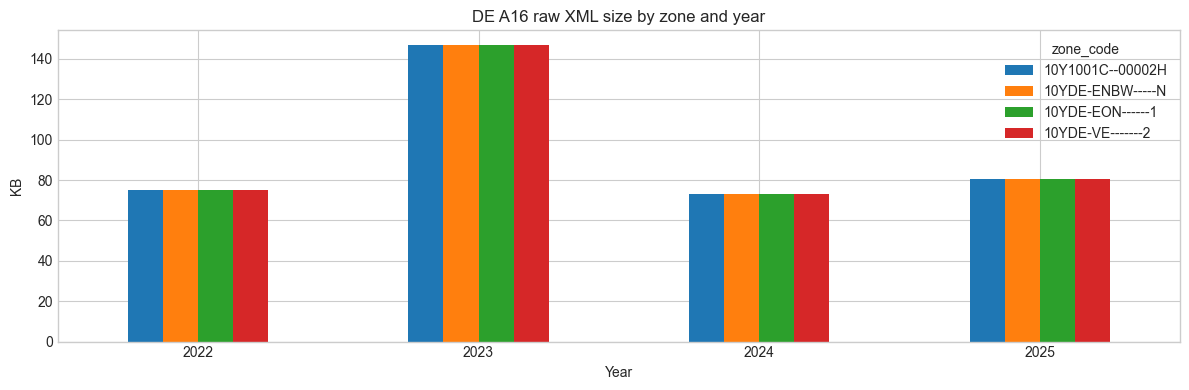

In [4]:
inventory_plot = (
    inventory_df.pivot_table(index="year", columns="zone_code", values="size_kb", aggfunc="sum")
    .sort_index()
)
inventory_plot.plot(kind="bar", figsize=(12, 4))
plt.title("DE A16 raw XML size by zone and year")
plt.ylabel("KB")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 2. Inspect One Raw XML Snippet

The DE files contain many short `TimeSeries` windows instead of a long continuous year chunk.


In [5]:
sample_path = sorted(RAW_DIR.glob("*.xml"))[0]
sample_text = sample_path.read_text(encoding="utf-8", errors="replace")

print("File:", sample_path.name)
print()
print("\n".join(sample_text.splitlines()[:100]))


File: 17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml

<?xml version="1.0" encoding="utf-8"?>
<Balancing_MarketDocument xmlns="urn:iec62325.351:tc57wg16:451-6:balancingdocument:4:1">
  <mRID>de66a2b04ba24491b961d4770d5ede7d</mRID>
  <revisionNumber>1</revisionNumber>
  <type>A84</type>
  <process.processType>A16</process.processType>
  <sender_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</sender_MarketParticipant.mRID>
  <sender_MarketParticipant.marketRole.type>A32</sender_MarketParticipant.marketRole.type>
  <receiver_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</receiver_MarketParticipant.mRID>
  <receiver_MarketParticipant.marketRole.type>A33</receiver_MarketParticipant.marketRole.type>
  <createdDateTime>2026-03-31T13:03:58Z</createdDateTime>
  <area_Domain.mRID codingScheme="A01">10Y1001C--00002H</area_Domain.mRID>
  <period.timeInterval>
    <start>2022-06-22T09:15Z</start>
    <end>2022-12-24T19:15Z</end>
  <

## 3. Parse Raw XML Into a Readable Native Points Table


In [6]:
points_raw, file_summary_df, parse_errors_df = cleaning.parse_xml_files(RAW_DIR)

print(f"Point rows parsed: {len(points_raw):,}")
print(f"Files parsed: {len(file_summary_df):,}")
print(f"Parse errors: {len(parse_errors_df):,}")

file_summary_df


Point rows parsed: 2,084
Files parsed: 16
Parse errors: 0


,source_file,source_zone_code,source_market_product_filter,source_year,source_offset,size_kb,created_datetime_utc,document_type_code,process_type_code,area_domain,area_domain_matches_filename_zone,document_period_start_utc,document_period_end_utc,point_rows,period_count,flow_direction_distribution,reported_resolution_distribution,price_category_distribution
0,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,10Y1001C--00002H,A01,2022,0,74.9,2026-03-31T13:03:58+00:00,A84,A16,10Y1001C--00002H,True,2022-06-22T09:15:00+00:00,2022-12-24T19:15:00+00:00,110,59,"{""A01"": 38, ""A02"": 21}","{""PT15M"": 59}","{""A08"": 110}"
1,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2023_offset_0000.xml,10Y1001C--00002H,A01,2023,0,146.8,2026-03-31T13:04:12+00:00,A84,A16,10Y1001C--00002H,True,2023-01-01T13:15:00+00:00,2023-12-27T13:00:00+00:00,195,123,"{""A01"": 87, ""A02"": 36}","{""PT15M"": 123}","{""A08"": 195}"
2,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2024_offset_0000.xml,10Y1001C--00002H,A01,2024,0,72.9,2026-03-31T13:04:25+00:00,A84,A16,10Y1001C--00002H,True,2024-01-09T05:45:00+00:00,2024-12-31T18:00:00+00:00,102,59,"{""A01"": 51, ""A02"": 8}","{""PT15M"": 59}","{""A08"": 102}"
3,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2025_offset_0000.xml,10Y1001C--00002H,A01,2025,0,80.6,2026-03-31T13:06:44+00:00,A84,A16,10Y1001C--00002H,True,2025-01-12T10:15:00+00:00,2025-12-30T19:15:00+00:00,114,65,"{""A01"": 45, ""A02"": 20}","{""PT15M"": 65}","{""A08"": 114}"
4,17_1_f_de_A16_(Realised)_10YDE-ENBW-----N_Standard_MarketProduct_A01_2022_offset_0000.xml,10YDE-ENBW-----N,A01,2022,0,74.9,2026-03-31T13:04:03+00:00,A84,A16,10YDE-ENBW-----N,True,2022-06-22T09:15:00+00:00,2022-12-24T19:15:00+00:00,110,59,"{""A01"": 38, ""A02"": 21}","{""PT15M"": 59}","{""A08"": 110}"
5,17_1_f_de_A16_(Realised)_10YDE-ENBW-----N_Standard_MarketProduct_A01_2023_offset_0000.xml,10YDE-ENBW-----N,A01,2023,0,146.8,2026-03-31T13:04:19+00:00,A84,A16,10YDE-ENBW-----N,True,2023-01-01T13:15:00+00:00,2023-12-27T13:00:00+00:00,195,123,"{""A01"": 87, ""A02"": 36}","{""PT15M"": 123}","{""A08"": 195}"
6,17_1_f_de_A16_(Realised)_10YDE-ENBW-----N_Standard_MarketProduct_A01_2024_offset_0000.xml,10YDE-ENBW-----N,A01,2024,0,72.9,2026-03-31T13:04:29+00:00,A84,A16,10YDE-ENBW-----N,True,2024-01-09T05:45:00+00:00,2024-12-31T18:00:00+00:00,102,59,"{""A01"": 51, ""A02"": 8}","{""PT15M"": 59}","{""A08"": 102}"
7,17_1_f_de_A16_(Realised)_10YDE-ENBW-----N_Standard_MarketProduct_A01_2025_offset_0000.xml,10YDE-ENBW-----N,A01,2025,0,80.6,2026-03-31T13:06:48+00:00,A84,A16,10YDE-ENBW-----N,True,2025-01-12T10:15:00+00:00,2025-12-30T19:15:00+00:00,114,65,"{""A01"": 45, ""A02"": 20}","{""PT15M"": 65}","{""A08"": 114}"
8,17_1_f_de_A16_(Realised)_10YDE-EON------1_Standard_MarketProduct_A01_2022_offset_0000.xml,10YDE-EON------1,A01,2022,0,74.9,2026-03-31T13:03:57+00:00,A84,A16,10YDE-EON------1,True,2022-06-22T09:15:00+00:00,2022-12-24T19:15:00+00:00,110,59,"{""A01"": 38, ""A02"": 21}","{""PT15M"": 59}","{""A08"": 110}"
9,17_1_f_de_A16_(Realised)_10YDE-EON------1_Standard_MarketProduct_A01_2023_offset_0000.xml,10YDE-EON------1,A01,2023,0,146.8,2026-03-31T13:04:06+00:00,A84,A16,10YDE-EON------1,True,2023-01-01T13:15:00+00:00,2023-12-27T13:00:00+00:00,195,123,"{""A01"": 87, ""A02"": 36}","{""PT15M"": 123}","{""A08"": 195}"


In [7]:
if not parse_errors_df.empty:
    parse_errors_df
else:
    print("No parse errors.")

readable_points = (
    points_raw[
        [
            "source_zone_code",
            "source_file",
            "flow_direction_label",
            "series_period_start_utc",
            "series_period_end_utc",
            "point_position",
            "point_timestamp_utc",
            "activation_price_eur_per_mwh",
            "imbalance_price_category_code",
            "area_domain_matches_filename_zone",
        ]
    ]
    .sort_values(["source_zone_code", "point_timestamp_utc", "flow_direction_label", "point_position"])
    .reset_index(drop=True)
)
readable_points.head(20)


No parse errors.


,source_zone_code,source_file,flow_direction_label,series_period_start_utc,series_period_end_utc,point_position,point_timestamp_utc,activation_price_eur_per_mwh,imbalance_price_category_code,area_domain_matches_filename_zone
0,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,Up,2022-06-22 09:15:00+00:00,2022-06-22 10:30:00+00:00,1,2022-06-22 09:15:00+00:00,892.68,A08,True
1,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,Up,2022-06-22 09:15:00+00:00,2022-06-22 10:30:00+00:00,3,2022-06-22 09:45:00+00:00,893.96,A08,True
2,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,Up,2022-06-22 09:15:00+00:00,2022-06-22 10:30:00+00:00,5,2022-06-22 10:15:00+00:00,1005.78,A08,True
3,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,Up,2022-06-22 19:15:00+00:00,2022-06-22 19:45:00+00:00,1,2022-06-22 19:15:00+00:00,1363.12,A08,True
4,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,Up,2022-06-23 14:00:00+00:00,2022-06-23 14:45:00+00:00,1,2022-06-23 14:00:00+00:00,1537.95,A08,True
5,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,Up,2022-06-23 14:00:00+00:00,2022-06-23 14:45:00+00:00,3,2022-06-23 14:30:00+00:00,1385.71,A08,True
6,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,Up,2022-06-23 17:45:00+00:00,2022-06-23 18:30:00+00:00,1,2022-06-23 17:45:00+00:00,1421.42,A08,True
7,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,Up,2022-06-23 17:45:00+00:00,2022-06-23 18:30:00+00:00,2,2022-06-23 18:00:00+00:00,1600.00,A08,True
8,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,Up,2022-06-23 17:45:00+00:00,2022-06-23 18:30:00+00:00,3,2022-06-23 18:15:00+00:00,1564.26,A08,True
9,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,Up,2022-06-24 08:30:00+00:00,2022-06-24 10:00:00+00:00,1,2022-06-24 08:30:00+00:00,1190.00,A08,True


## 4. Diagnose Native Structure and Zone-Level Quality


In [8]:
points_long, duplicates_removed = cleaning.deduplicate_points(points_raw)
period_diagnostics = cleaning.build_period_diagnostics(points_long)
points_summary = cleaning.summarize_points(points_long)

overview_df = pd.DataFrame(
    [
        {"metric": "Point rows after deduplication", "value": len(points_long)},
        {"metric": "Duplicates removed", "value": len(duplicates_removed)},
        {"metric": "Unique zones", "value": points_long["source_zone_code"].nunique()},
        {"metric": "Unique directions", "value": ", ".join(sorted(points_long["flow_direction_label"].dropna().unique()))},
        {"metric": "Unique price categories", "value": ", ".join(sorted(points_long["imbalance_price_category_code"].dropna().unique()))},
        {"metric": "Area domain matches filename zone for all rows", "value": bool(points_long["area_domain_matches_filename_zone"].fillna(False).all())},
    ]
)
overview_df


,metric,value
0,Point rows after deduplication,2084
1,Duplicates removed,0
2,Unique zones,4
3,Unique directions,"Down, Up"
4,Unique price categories,A08
5,Area domain matches filename zone for all rows,True


In [9]:
points_summary


,source_zone_code,flow_direction_code,flow_direction_label,rows,unique_periods,min_point_timestamp_utc,max_point_timestamp_utc,price_category_distribution
0,10Y1001C--00002H,A01,Up,395,221,2022-06-22T09:15:00+00:00,2025-12-30T19:00:00+00:00,"{""A08"": 395}"
1,10Y1001C--00002H,A02,Down,126,85,2022-06-30T16:15:00+00:00,2025-11-17T16:15:00+00:00,"{""A08"": 126}"
2,10YDE-ENBW-----N,A01,Up,395,221,2022-06-22T09:15:00+00:00,2025-12-30T19:00:00+00:00,"{""A08"": 395}"
3,10YDE-ENBW-----N,A02,Down,126,85,2022-06-30T16:15:00+00:00,2025-11-17T16:15:00+00:00,"{""A08"": 126}"
4,10YDE-EON------1,A01,Up,395,221,2022-06-22T09:15:00+00:00,2025-12-30T19:00:00+00:00,"{""A08"": 395}"
5,10YDE-EON------1,A02,Down,126,85,2022-06-30T16:15:00+00:00,2025-11-17T16:15:00+00:00,"{""A08"": 126}"
6,10YDE-VE-------2,A01,Up,395,221,2022-06-22T09:15:00+00:00,2025-12-30T19:00:00+00:00,"{""A08"": 395}"
7,10YDE-VE-------2,A02,Down,126,85,2022-06-30T16:15:00+00:00,2025-11-17T16:15:00+00:00,"{""A08"": 126}"


In [10]:
period_diagnostics.head(20)


,source_zone_code,source_file,timeseries_index,timeseries_mrid,period_index,flow_direction_code,flow_direction_label,business_type_code,standard_market_product_type_code,psr_type_code,curve_type_code,curve_type_label,series_period_start_utc,series_period_end_utc,reported_resolution,reported_resolution_minutes,expected_dense_point_count,point_count,first_position,last_position,first_point_timestamp_utc,last_point_timestamp_utc,unique_price_levels,unique_price_categories,period_duration_minutes,compression_ratio_vs_dense_grid,first_position_gt_1,has_sparse_gaps_between_positions
0,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,1,1,1,A01,Up,A97,A01,A03,A03,Variable_block_curve,2022-06-22 09:15:00+00:00,2022-06-22 10:30:00+00:00,PT15M,15,5,3,1,5,2022-06-22 09:15:00+00:00,2022-06-22 10:15:00+00:00,3,1,75,0.6,False,True
1,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,2,2,1,A01,Up,A97,A01,A03,A03,Variable_block_curve,2022-06-22 19:15:00+00:00,2022-06-22 19:45:00+00:00,PT15M,15,2,1,1,1,2022-06-22 19:15:00+00:00,2022-06-22 19:15:00+00:00,1,1,30,0.5,False,False
2,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,3,3,1,A01,Up,A97,A01,A03,A03,Variable_block_curve,2022-06-23 14:00:00+00:00,2022-06-23 14:45:00+00:00,PT15M,15,3,2,1,3,2022-06-23 14:00:00+00:00,2022-06-23 14:30:00+00:00,2,1,45,0.666667,False,True
3,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,4,4,1,A01,Up,A97,A01,A03,A03,Variable_block_curve,2022-06-23 17:45:00+00:00,2022-06-23 18:30:00+00:00,PT15M,15,3,3,1,3,2022-06-23 17:45:00+00:00,2022-06-23 18:15:00+00:00,3,1,45,1.0,False,False
4,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,5,5,1,A01,Up,A97,A01,A03,A03,Variable_block_curve,2022-06-24 08:30:00+00:00,2022-06-24 10:00:00+00:00,PT15M,15,6,4,1,6,2022-06-24 08:30:00+00:00,2022-06-24 09:45:00+00:00,4,1,90,0.666667,False,True
5,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,6,6,1,A01,Up,A97,A01,A03,A03,Variable_block_curve,2022-06-24 11:15:00+00:00,2022-06-24 12:00:00+00:00,PT15M,15,3,3,1,3,2022-06-24 11:15:00+00:00,2022-06-24 11:45:00+00:00,3,1,45,1.0,False,False
6,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,7,7,1,A01,Up,A97,A01,A03,A03,Variable_block_curve,2022-06-24 14:45:00+00:00,2022-06-24 15:15:00+00:00,PT15M,15,2,1,1,1,2022-06-24 14:45:00+00:00,2022-06-24 14:45:00+00:00,1,1,30,0.5,False,False
7,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,8,8,1,A01,Up,A97,A01,A03,A03,Variable_block_curve,2022-06-24 15:30:00+00:00,2022-06-24 16:15:00+00:00,PT15M,15,3,3,1,3,2022-06-24 15:30:00+00:00,2022-06-24 16:00:00+00:00,3,1,45,1.0,False,False
8,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,9,9,1,A01,Up,A97,A01,A03,A03,Variable_block_curve,2022-06-27 07:30:00+00:00,2022-06-27 08:45:00+00:00,PT15M,15,5,4,1,5,2022-06-27 07:30:00+00:00,2022-06-27 08:30:00+00:00,4,1,75,0.8,False,True
9,10Y1001C--00002H,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,10,10,1,A01,Up,A97,A01,A03,A03,Variable_block_curve,2022-06-27 09:45:00+00:00,2022-06-27 10:15:00+00:00,PT15M,15,2,2,1,2,2022-06-27 09:45:00+00:00,2022-06-27 10:00:00+00:00,2,1,30,1.0,False,False


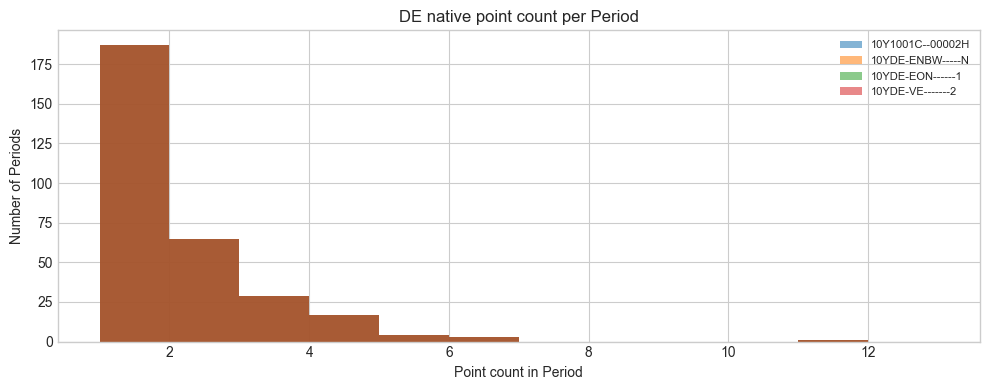

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
for zone_code, group in period_diagnostics.groupby("source_zone_code"):
    ax.hist(group["point_count"], bins=range(1, 14), alpha=0.55, label=zone_code)
ax.set_title("DE native point count per Period")
ax.set_xlabel("Point count in Period")
ax.set_ylabel("Number of Periods")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. Turn Native Points Into Blocks and Zone-Level Quarter-Hours


In [12]:
blocks_long = cleaning.build_blocks(points_long)
zone_quarterhour_long = cleaning.expand_blocks_to_quarterhour(blocks_long)
zone_quarterhour_wide = cleaning.build_zone_quarterhour_wide(zone_quarterhour_long)
zone_hourly_long = cleaning.aggregate_zone_hourly(zone_quarterhour_long)

print(f"Block rows: {len(blocks_long):,}")
print(f"Zone quarter-hour rows: {len(zone_quarterhour_long):,}")
print(f"Zone hourly rows: {len(zone_hourly_long):,}")
blocks_long.head(20)


Block rows: 2,084
Zone quarter-hour rows: 2,396
Zone hourly rows: 1,508


,block_id,family,market,source_file,source_zone_code,source_market_product_filter,source_year,source_offset,created_datetime_utc,document_type_code,document_type_label,process_type_code,process_type_label,area_domain,area_domain_matches_filename_zone,timeseries_index,timeseries_mrid,period_index,business_type_code,business_type_label,standard_market_product_type_code,psr_type_code,flow_direction_code,flow_direction_label,curve_type_code,curve_type_label,currency_unit,price_measure_unit,series_period_start_utc,series_period_end_utc,reported_resolution,reported_resolution_minutes,point_count_in_period,expected_dense_point_count,point_position,native_point_timestamp_utc,next_point_position,next_point_timestamp_utc,block_start_utc,block_end_utc,block_duration_minutes,block_quarterhour_count,block_position_step,block_interpretation,activation_price_eur_per_mwh,imbalance_price_category_code,imbalance_price_category_label
0,1,17_1_f_de_a16_realised,DE,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,10Y1001C--00002H,A01,2022,0,2026-03-31 13:03:58+00:00,A84,A84,A16,A16,10Y1001C--00002H,True,1,1,1,A97,A97,A01,A03,A01,Up,A03,Variable_block_curve,EUR,MWH,2022-06-22 09:15:00+00:00,2022-06-22 10:30:00+00:00,PT15M,15,3,5,1,2022-06-22 09:15:00+00:00,3,2022-06-22 09:45:00+00:00,2022-06-22 09:15:00+00:00,2022-06-22 09:45:00+00:00,30,2,2,change_point_to_next_position,892.68,A08,A08
1,2,17_1_f_de_a16_realised,DE,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,10Y1001C--00002H,A01,2022,0,2026-03-31 13:03:58+00:00,A84,A84,A16,A16,10Y1001C--00002H,True,1,1,1,A97,A97,A01,A03,A01,Up,A03,Variable_block_curve,EUR,MWH,2022-06-22 09:15:00+00:00,2022-06-22 10:30:00+00:00,PT15M,15,3,5,3,2022-06-22 09:45:00+00:00,5,2022-06-22 10:15:00+00:00,2022-06-22 09:45:00+00:00,2022-06-22 10:15:00+00:00,30,2,2,change_point_to_next_position,893.96,A08,A08
2,3,17_1_f_de_a16_realised,DE,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,10Y1001C--00002H,A01,2022,0,2026-03-31 13:03:58+00:00,A84,A84,A16,A16,10Y1001C--00002H,True,1,1,1,A97,A97,A01,A03,A01,Up,A03,Variable_block_curve,EUR,MWH,2022-06-22 09:15:00+00:00,2022-06-22 10:30:00+00:00,PT15M,15,3,5,5,2022-06-22 10:15:00+00:00,<NA>,NaT,2022-06-22 10:15:00+00:00,2022-06-22 10:30:00+00:00,15,1,<NA>,last_point_to_period_end,1005.78,A08,A08
3,4,17_1_f_de_a16_realised,DE,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,10Y1001C--00002H,A01,2022,0,2026-03-31 13:03:58+00:00,A84,A84,A16,A16,10Y1001C--00002H,True,2,2,1,A97,A97,A01,A03,A01,Up,A03,Variable_block_curve,EUR,MWH,2022-06-22 19:15:00+00:00,2022-06-22 19:45:00+00:00,PT15M,15,1,2,1,2022-06-22 19:15:00+00:00,<NA>,NaT,2022-06-22 19:15:00+00:00,2022-06-22 19:45:00+00:00,30,2,<NA>,last_point_to_period_end,1363.12,A08,A08
4,5,17_1_f_de_a16_realised,DE,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,10Y1001C--00002H,A01,2022,0,2026-03-31 13:03:58+00:00,A84,A84,A16,A16,10Y1001C--00002H,True,3,3,1,A97,A97,A01,A03,A01,Up,A03,Variable_block_curve,EUR,MWH,2022-06-23 14:00:00+00:00,2022-06-23 14:45:00+00:00,PT15M,15,2,3,1,2022-06-23 14:00:00+00:00,3,2022-06-23 14:30:00+00:00,2022-06-23 14:00:00+00:00,2022-06-23 14:30:00+00:00,30,2,2,change_point_to_next_position,1537.95,A08,A08
5,6,17_1_f_de_a16_realised,DE,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,10Y1001C--00002H,A01,2022,0,2026-03-31 13:03:58+00:00,A84,A84,A16,A16,10Y1001C--00002H,True,3,3,1,A97,A97,A01,A03,A01,Up,A03,Variable_block_curve,EUR,MWH,2022-06-23 14:00:00+00:00,2022-06-23 14:45:00+00:00,PT15M,15,2,3,3,2022-06-23 14:30:00+00:00,<NA>,NaT,2022-06-23 14:30:00+00:00,2022-06-23 14:45:00+00:00,15,1,<NA>,last_point_to_period_end,1385.71,A08,A08
6,7,17_1_f_de_a16_realised,DE,17_1_f_de_A16_(Realised)_10Y1001C--00002H_Standard_MarketProduct_A01_2022_offset_0000.xml,10Y1001C--00002H

In [13]:
zone_quarterhour_summary = cleaning.summarize_zone_quarterhour(zone_quarterhour_long)
zone_hourly_summary = cleaning.summarize_zone_hourly(zone_hourly_long)

zone_quarterhour_summary


,source_zone_code,flow_direction_code,flow_direction_label,rows,unique_intervals,min_timestamp_utc,max_interval_end_utc
0,10Y1001C--00002H,A01,Up,452,452,2022-06-22T09:15:00+00:00,2025-12-30T19:15:00+00:00
1,10Y1001C--00002H,A02,Down,147,147,2022-06-30T16:15:00+00:00,2025-11-17T16:30:00+00:00
2,10YDE-ENBW-----N,A01,Up,452,452,2022-06-22T09:15:00+00:00,2025-12-30T19:15:00+00:00
3,10YDE-ENBW-----N,A02,Down,147,147,2022-06-30T16:15:00+00:00,2025-11-17T16:30:00+00:00
4,10YDE-EON------1,A01,Up,452,452,2022-06-22T09:15:00+00:00,2025-12-30T19:15:00+00:00
5,10YDE-EON------1,A02,Down,147,147,2022-06-30T16:15:00+00:00,2025-11-17T16:30:00+00:00
6,10YDE-VE-------2,A01,Up,452,452,2022-06-22T09:15:00+00:00,2025-12-30T19:15:00+00:00
7,10YDE-VE-------2,A02,Down,147,147,2022-06-30T16:15:00+00:00,2025-11-17T16:30:00+00:00


In [14]:
zone_hourly_summary


,source_zone_code,flow_direction_code,flow_direction_label,rows,unique_hours,full_coverage_hours,partial_hours
0,10Y1001C--00002H,A01,Up,280,280,8,272
1,10Y1001C--00002H,A02,Down,97,97,4,93
2,10YDE-ENBW-----N,A01,Up,280,280,8,272
3,10YDE-ENBW-----N,A02,Down,97,97,4,93
4,10YDE-EON------1,A01,Up,280,280,8,272
5,10YDE-EON------1,A02,Down,97,97,4,93
6,10YDE-VE-------2,A01,Up,280,280,8,272
7,10YDE-VE-------2,A02,Down,97,97,4,93


## 6. Compare Zones for Validity and Potential Raw-Data Mistakes

This is the critical DE-specific diagnostic. We compare the zone-level quarter-hour series pairwise before building the combined-DE layer.


In [15]:
zone_pair_comparison = cleaning.build_zone_pair_comparison(zone_quarterhour_long)
zone_pair_comparison


,left_zone_code,right_zone_code,left_rows,right_rows,matching_rows,left_only_rows,right_only_rows,price_diff_rows,category_diff_rows,identical_quarterhour_series
0,10Y1001C--00002H,10YDE-ENBW-----N,599,599,599,0,0,0,0,True
1,10Y1001C--00002H,10YDE-EON------1,599,599,599,0,0,0,0,True
2,10Y1001C--00002H,10YDE-VE-------2,599,599,599,0,0,0,0,True
3,10YDE-ENBW-----N,10YDE-EON------1,599,599,599,0,0,0,0,True
4,10YDE-ENBW-----N,10YDE-VE-------2,599,599,599,0,0,0,0,True
5,10YDE-EON------1,10YDE-VE-------2,599,599,599,0,0,0,0,True


In [16]:
combined_quarterhour_long = cleaning.build_combined_quarterhour(zone_quarterhour_long)
combined_quarterhour_wide = cleaning.build_combined_quarterhour_wide(combined_quarterhour_long)
combined_hourly_long = cleaning.aggregate_combined_hourly(combined_quarterhour_long)
combined_hourly_wide = cleaning.build_combined_hourly_wide(combined_hourly_long)
combined_quarterhour_summary = cleaning.summarize_combined_quarterhour(combined_quarterhour_long)
combined_hourly_summary = cleaning.summarize_combined_hourly(combined_hourly_long)
cross_zone_duplicate_summary = cleaning.build_cross_zone_duplicate_summary(combined_quarterhour_long)

combined_quarterhour_summary


,flow_direction_code,flow_direction_label,rows,unique_intervals,min_reporting_zone_count,max_reporting_zone_count,zone_conflict_rows
0,A01,Up,452,452,4,4,0
1,A02,Down,147,147,4,4,0


In [17]:
validity_overview = pd.DataFrame(
    [
        {"metric": "Quarter-hours with all 4 zones reporting", "value": int((combined_quarterhour_long["reporting_zone_count"] == cleaning.EXPECTED_ZONE_COUNT).sum())},
        {"metric": "Quarter-hours with zone conflicts", "value": int((~combined_quarterhour_long["all_zone_values_identical"]).sum())},
        {"metric": "Quarter-hours that are exact cross-zone duplicates", "value": int(cross_zone_duplicate_summary["is_exact_cross_zone_duplicate"].sum())},
        {"metric": "All pairwise zone series identical", "value": bool(zone_pair_comparison["identical_quarterhour_series"].all())},
    ]
)
validity_overview


,metric,value
0,Quarter-hours with all 4 zones reporting,599
1,Quarter-hours with zone conflicts,0
2,Quarter-hours that are exact cross-zone duplicates,599
3,All pairwise zone series identical,True


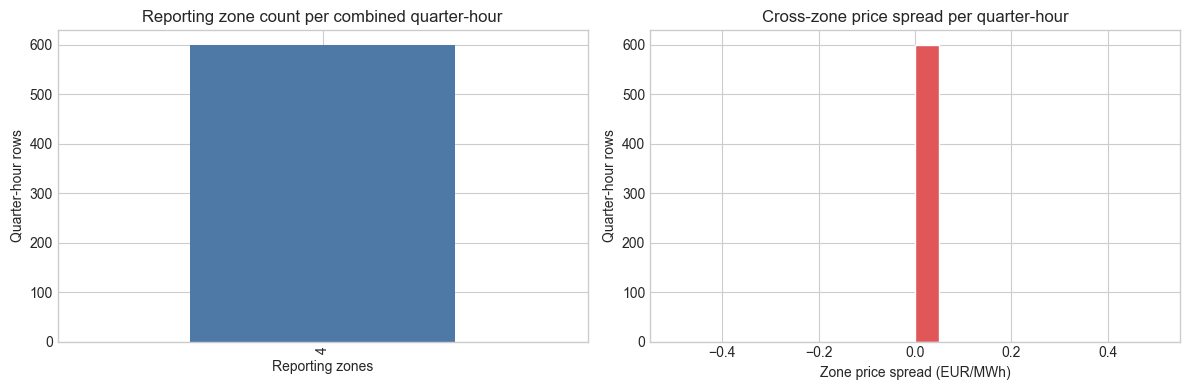

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

combined_quarterhour_long["reporting_zone_count"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#4E79A7"
)
axes[0].set_title("Reporting zone count per combined quarter-hour")
axes[0].set_xlabel("Reporting zones")
axes[0].set_ylabel("Quarter-hour rows")

axes[1].hist(combined_quarterhour_long["zone_price_spread_eur_per_mwh"], bins=20, color="#E15759", edgecolor="white")
axes[1].set_title("Cross-zone price spread per quarter-hour")
axes[1].set_xlabel("Zone price spread (EUR/MWh)")
axes[1].set_ylabel("Quarter-hour rows")

plt.tight_layout()
plt.show()


## 7. Visualise an Objective Active Day

Select the local day with the highest number of active combined quarter-hours. If there is a tie, pick the one with the highest absolute combined price.


In [19]:
combined_plot = combined_quarterhour_long.copy()
combined_plot["local_date"] = combined_plot["timestamp_utc"].dt.tz_convert(cleaning.MARKET_TIMEZONE).dt.date
activity = (
    combined_plot.groupby("local_date", as_index=False)
    .agg(
        active_quarterhours=("timestamp_utc", "size"),
        max_abs_price=("combined_activation_price_eur_per_mwh", lambda s: s.abs().max()),
    )
    .sort_values(["active_quarterhours", "max_abs_price"], ascending=[False, False])
)
sample_day = pd.to_datetime(activity.iloc[0]["local_date"])

print("Selected local day:", sample_day.date())
activity.head(10)


Selected local day: 2024-01-09


,local_date,active_quarterhours,max_abs_price
121,2024-01-09,16,15000.00
119,2023-12-23,15,513.54
2,2022-06-24,14,4269.57
58,2023-04-04,11,1940.66
56,2023-03-28,10,1416.63
3,2022-06-27,10,1100.00
75,2023-06-19,8,7999.00
202,2025-09-01,8,547.70
209,2025-10-28,8,400.00
146,2024-06-03,7,15000.00


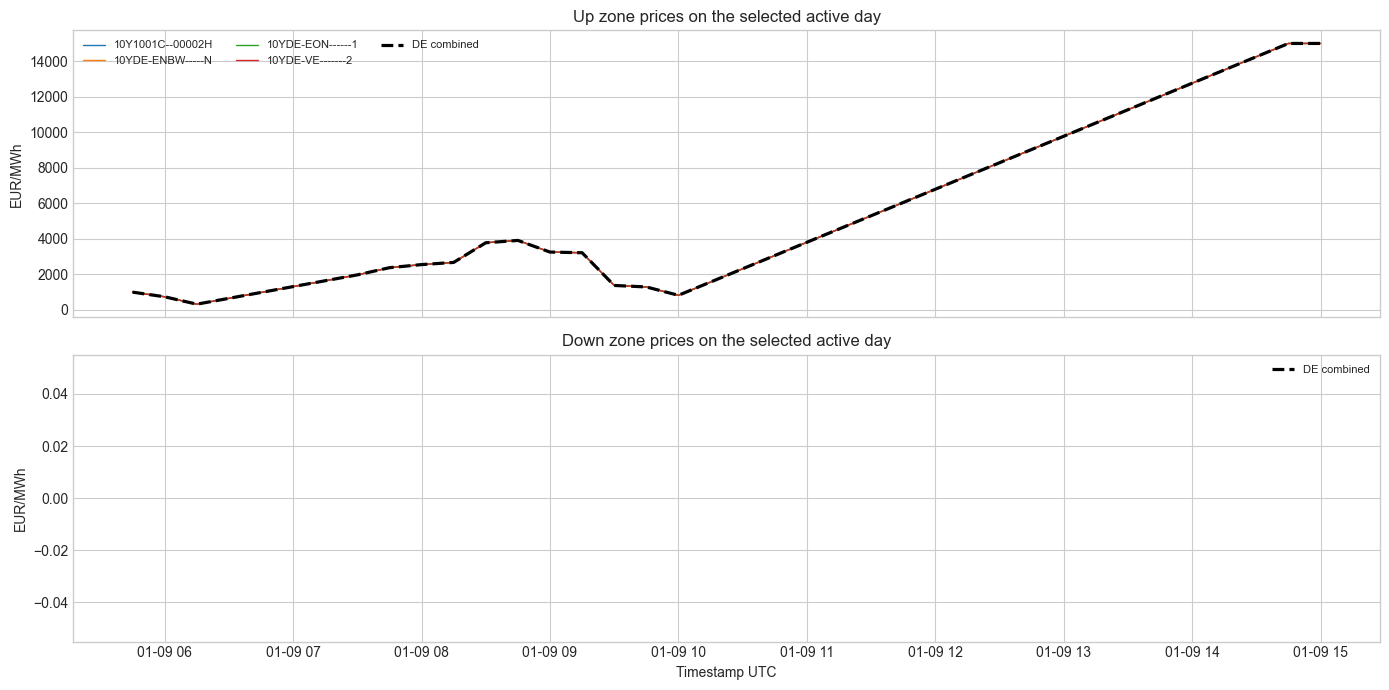

In [20]:
zone_day = zone_quarterhour_long[
    zone_quarterhour_long["timestamp_utc"].dt.tz_convert(cleaning.MARKET_TIMEZONE).dt.date == sample_day.date()
].copy()
combined_day = combined_quarterhour_long[
    combined_quarterhour_long["timestamp_utc"].dt.tz_convert(cleaning.MARKET_TIMEZONE).dt.date == sample_day.date()
].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, direction in zip(axes, ["Up", "Down"]):
    zone_sub = zone_day.loc[zone_day["flow_direction_label"] == direction]
    for zone_code, group in zone_sub.groupby("source_zone_code"):
        ax.plot(group["timestamp_utc"], group["activation_price_eur_per_mwh"], linewidth=1.0, label=zone_code)
    combined_sub = combined_day.loc[combined_day["flow_direction_label"] == direction]
    ax.plot(
        combined_sub["timestamp_utc"],
        combined_sub["combined_activation_price_eur_per_mwh"],
        linewidth=2.3,
        color="black",
        linestyle="--",
        label="DE combined",
    )
    ax.set_title(f"{direction} zone prices on the selected active day")
    ax.set_ylabel("EUR/MWh")
    ax.legend(fontsize=8, ncol=3)
axes[-1].set_xlabel("Timestamp UTC")
plt.tight_layout()
plt.show()


## 8. Inspect the Combined-DE Hourly Layer


In [21]:
combined_hourly_summary


,flow_direction_code,flow_direction_label,rows,unique_hours,full_coverage_hours,partial_hours,hours_with_zone_conflicts
0,A01,Up,280,280,8,272,0
1,A02,Down,97,97,4,93,0


In [22]:
combined_hourly_long.head(20)


,family,market,combined_market_code,timestamp_utc,flow_direction_code,flow_direction_label,quarterhour_count,combined_activation_price_mean_eur_per_mwh,combined_activation_price_min_eur_per_mwh,combined_activation_price_max_eur_per_mwh,min_reporting_zone_count,max_reporting_zone_count,conflict_quarterhour_count,coverage_minutes,expected_coverage_minutes,is_complete_hour,combined_activation_price_spread_eur_per_mwh,interval_end_utc,known_at_utc,known_at_rule,has_zone_conflict_in_hour,target_delivery_local_date,target_hour_local,target_minute_local
0,17_1_f_de_a16_realised,DE,DE_combined,2022-06-22 09:00:00+00:00,A01,Up,3,893.106667,892.68,893.96,4,4,0,45,60,False,1.28,2022-06-22 10:00:00+00:00,NaT,realised_a16_not_forecast_safe,False,2022-06-22,11,0
1,17_1_f_de_a16_realised,DE,DE_combined,2022-06-22 10:00:00+00:00,A01,Up,2,949.870000,893.96,1005.78,4,4,0,30,60,False,111.82,2022-06-22 11:00:00+00:00,NaT,realised_a16_not_forecast_safe,False,2022-06-22,12,0
2,17_1_f_de_a16_realised,DE,DE_combined,2022-06-22 19:00:00+00:00,A01,Up,2,1363.120000,1363.12,1363.12,4,4,0,30,60,False,0.00,2022-06-22 20:00:00+00:00,NaT,realised_a16_not_forecast_safe,False,2022-06-22,21,0
3,17_1_f_de_a16_realised,DE,DE_combined,2022-06-23 14:00:00+00:00,A01,Up,3,1487.203333,1385.71,1537.95,4,4,0,45,60,False,152.24,2022-06-23 15:00:00+00:00,NaT,realised_a16_not_forecast_safe,False,2022-06-23,16,0
4,17_1_f_de_a16_realised,DE,DE_combined,2022-06-23 17:00:00+00:00,A01,Up,1,1421.420000,1421.42,1421.42,4,4,0,15,60,False,0.00,2022-06-23 18:00:00+00:00,NaT,realised_a16_not_forecast_safe,False,2022-06-23,19,0
5,17_1_f_de_a16_realised,DE,DE_combined,2022-06-23 18:00:00+00:00,A01,Up,2,1582.130000,1564.26,1600.00,4,4,0,30,60,False,35.74,2022-06-23 19:00:00+00:00,NaT,realised_a16_not_forecast_safe,False,2022-06-23,20,0
6,17_1_f_de_a16_realised,DE,DE_combined,2022-06-24 08:00:00+00:00,A01,Up,2,1215.000000,1190.00,1240.00,4,4,0,30,60,False,50.00,2022-06-24 09:00:00+00:00,NaT,realised_a16_not_forecast_safe,False,2022-06-24,10,0
7,17_1_f_de_a16_realised,DE,DE_combined,2022-06-24 09:00:00+00:00,A01,Up,4,1335.000000,1140.00,1400.00,4,4,0,60,60,True,260.00,2022-06-24 10:00:00+00:00,NaT,realised_a16_not_forecast_safe,False,2022-06-24,11,0
8,17_1_f_de_a16_realised,DE,DE_combined,2022-06-24 11:00:00+00:00,A01,Up,3,937.796667,755.00,1086.56,4,4,0,45,60,False,331.56,2022-06-24 12:00:00+00:00,NaT,realised_a16_not_forecast_safe,False,2022-06-24,13,0
9,17_1_f_de_a16_realised,DE,DE_combined,2022-06-24 14:00:00+00:00,A01,Up,1,991.680000,991.68,991.68,4,4,0,15,60,False,0.00,2022-06-24 15:00:00+00:00,NaT,realised_a16_not_forecast_safe,False,2022-06-24,16,0


## 9. Write the Cleaned Outputs


In [23]:
cleaning.write_outputs(
    OUTPUT_DIR,
    points_raw=points_raw,
    file_summary=file_summary_df,
    parse_errors=parse_errors_df,
    points_long=points_long,
    duplicates_removed=duplicates_removed,
    period_diagnostics=period_diagnostics,
    blocks_long=blocks_long,
    zone_quarterhour_long=zone_quarterhour_long,
    zone_quarterhour_wide=zone_quarterhour_wide,
    combined_quarterhour_long=combined_quarterhour_long,
    combined_quarterhour_wide=combined_quarterhour_wide,
    zone_hourly_long=zone_hourly_long,
    combined_hourly_long=combined_hourly_long,
    combined_hourly_wide=combined_hourly_wide,
    points_summary=points_summary,
    blocks_summary=cleaning.summarize_blocks(blocks_long),
    zone_quarterhour_summary=zone_quarterhour_summary,
    combined_quarterhour_summary=combined_quarterhour_summary,
    zone_hourly_summary=zone_hourly_summary,
    combined_hourly_summary=combined_hourly_summary,
    zone_pair_comparison=zone_pair_comparison,
    cross_zone_duplicate_summary=cross_zone_duplicate_summary,
)

saved_files = sorted(str(path.relative_to(OUTPUT_DIR)) for path in OUTPUT_DIR.rglob("*") if path.is_file())
pd.DataFrame({"saved_file": saved_files}).head(60)


,saved_file
0,diagnostics\blocks_summary.csv
1,diagnostics\combined_hourly_summary.csv
2,diagnostics\combined_quarterhour_summary.csv
3,diagnostics\cross_zone_duplicate_summary.csv
4,diagnostics\duplicates_removed.csv
5,diagnostics\file_summary.csv
6,diagnostics\metadata.json
7,diagnostics\parse_errors.csv
8,diagnostics\period_diagnostics.csv
9,diagnostics\points_summary.csv
